# Automated Causal Abstraction — Project Walkthrough

This notebook documents the main parts used w.r.t DAS and how to run them:

1. **Boundless DAS** — DAS that *learns* the subspace width `k` instead of fixing it.
2. **Node-level DAS** — DAS localised to a single component (block / MLP / attention / head).
3. **Visualization scripts** — the plotting tools and the figures they produced.

For each part there is a short **“How is its output produced”** (what the code does) and
**“What has this produced”** (the files / figures it wrote).

> **Assumptions:** run this notebook from the repository root (`automated-causal-abstraction/`).
> The heavy training commands need a GPU and are shown but not executed here. The analysis /
> plotting snippets are lightweight and read the results that already exist.

In [1]:
import os, json, glob
from IPython.display import Image, display

# Paths (adjust if your layout differs)
REPO    = os.getcwd()                     # repository root
RESULTS = os.path.join(REPO, 'results')   # DAS / per-node report JSONs + checkpoints
PLOTS   = os.path.join(REPO, '..', 'presentation_plots')  # rendered figures

def show(path, width=760):
    """Display a PNG if it exists, else print where it should be."""
    if os.path.exists(path):
        display(Image(filename=path, width=width))
    else:
        print('(not found:', path, ')')

print('REPO   =', REPO)
print('RESULTS=', RESULTS)
print('PLOTS  =', os.path.abspath(PLOTS))

REPO   = /Users/jonaprinz/studies/Uni/Causality Seminar/automated-causal-abstraction
RESULTS= /Users/jonaprinz/studies/Uni/Causality Seminar/automated-causal-abstraction/results
PLOTS  = /Users/jonaprinz/studies/Uni/Causality Seminar/presentation_plots


---
## 1. Boundless DAS

Standard DAS fixes the subspace size `k` by hand (the paper sweeps `k ∈ {64,128,256}`).
**Boundless DAS** is given the *full* 768-dim residual stream and trains a soft mask that
learns how many dimensions the intermediate variable `P` actually needs, turning `k` from a
hyperparameter into a measurement.

It uses pyvene's `BoundlessRotatedSpaceIntervention` on `block_output`, with the base model
frozen and Adam training the rotation **and** the boundary (the temperature is annealed each
step). One run per (causal model, layer), checkpoints are saved to:

```
results/arithmetic/intervenable_models/cm_<id>/intervenable_768_<layer>
```

### How to use it (training)

Boundless training is `run_das.py` with the `--boundless` flag, same loop as fixed-`k` DAS,
but it swaps in `BoundlessRotatedSpaceIntervention` and sets `low_rank_dimension = 768` (the
full stream) with `subspaces=None`:

```bash
python3 src/run_das.py --boundless --causal_model_type arithmetic \
    --n_training 25000 --epochs 10 --batch_size 512 --seed 43
```

* **With `--boundless`** → writes `intervenable_768_<layer>` (learned `k`).
* **Without `--boundless`** → the fixed-`k` baseline: sweeps `{64,128,256}` and writes
  `intervenable_{64,128,256}_<layer>` plus the report JSONs `visualize_boundless_das.py` reads.

(Run on GPU, the boundary is a small extra parameter on top of the rotation.)

### How is its output produced

Each `BoundlessRotatedSpaceIntervention` stores a learnable `intervention_boundaries` (a
*fraction* of the embedding dim) and a `temperature`. The active dimension is read out as:

* **hard** `k = round(boundary_fraction × 768)`
* **soft** `k = Σ sigmoid-mask` over the 768 dims (the honest count, since the mask is soft).

The snippet below loads one checkpoint and prints both. (`plot_boundless_dimensions.py`
does this for every checkpoint and plots it, see below.)

In [3]:
# Read the learned dimensionality from one Boundless checkpoint.
try:
    import torch, pyvene as pv
    from transformers import GPT2ForSequenceClassification

    ckpt = os.path.join(RESULTS, 'arithmetic', 'intervenable_models', 'cm_1', 'intervenable_768_0')
    base = GPT2ForSequenceClassification.from_pretrained('mara589/arithmetic-gpt2')
    m = pv.IntervenableModel.load(ckpt, model=base)
    module = m.interventions[list(m.interventions.keys())[0]]
    frac = float(torch.clamp(module.intervention_boundaries.detach().cpu(), 1e-3, 1).flatten()[0])
    print(f'learned boundary fraction : {frac:.4f}')
    print(f'hard k = round(frac*768)  : {round(frac*768)}')
except Exception as e:
    print('Skipping live load (', type(e).__name__, e, ')')
    print('Use src/plot_boundless_dimensions.py on the cluster where pyvene + checkpoints live.')

Skipping live load ( HFValidationError Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/Users/jonaprinz/studies/Uni/Causality Seminar/automated-causal-abstraction/results/arithmetic/intervenable_models/cm_1/intervenable_768_0'. Use `repo_type` argument if needed. )
Use src/plot_boundless_dimensions.py on the cluster where pyvene + checkpoints live.


### How to use it (analysis)

```bash
# learned-k-per-layer plot (hard + soft) and the IIA-vs-k efficiency frontier
python3 src/plot_boundless_dimensions.py \
    --root results/arithmetic/intervenable_models \
    --reports_root results/arithmetic          # enables the frontier (needs IIA reports)
```

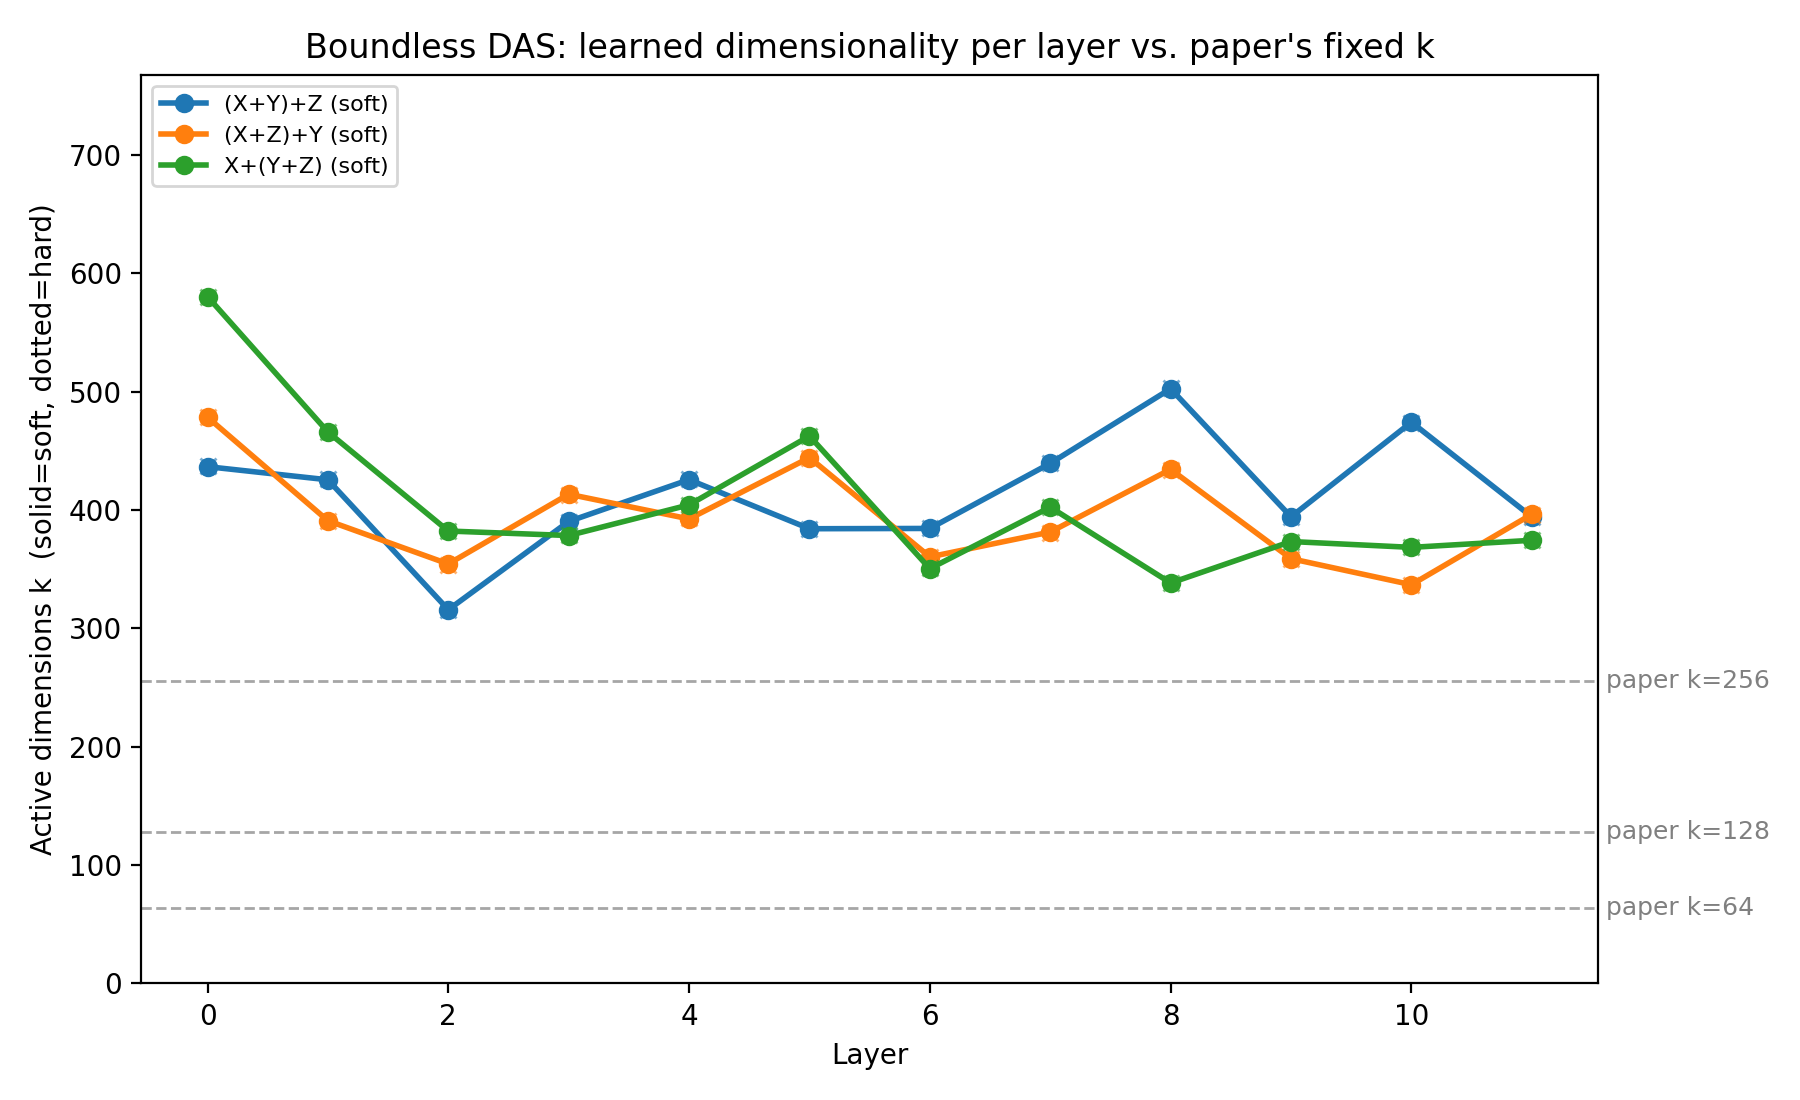

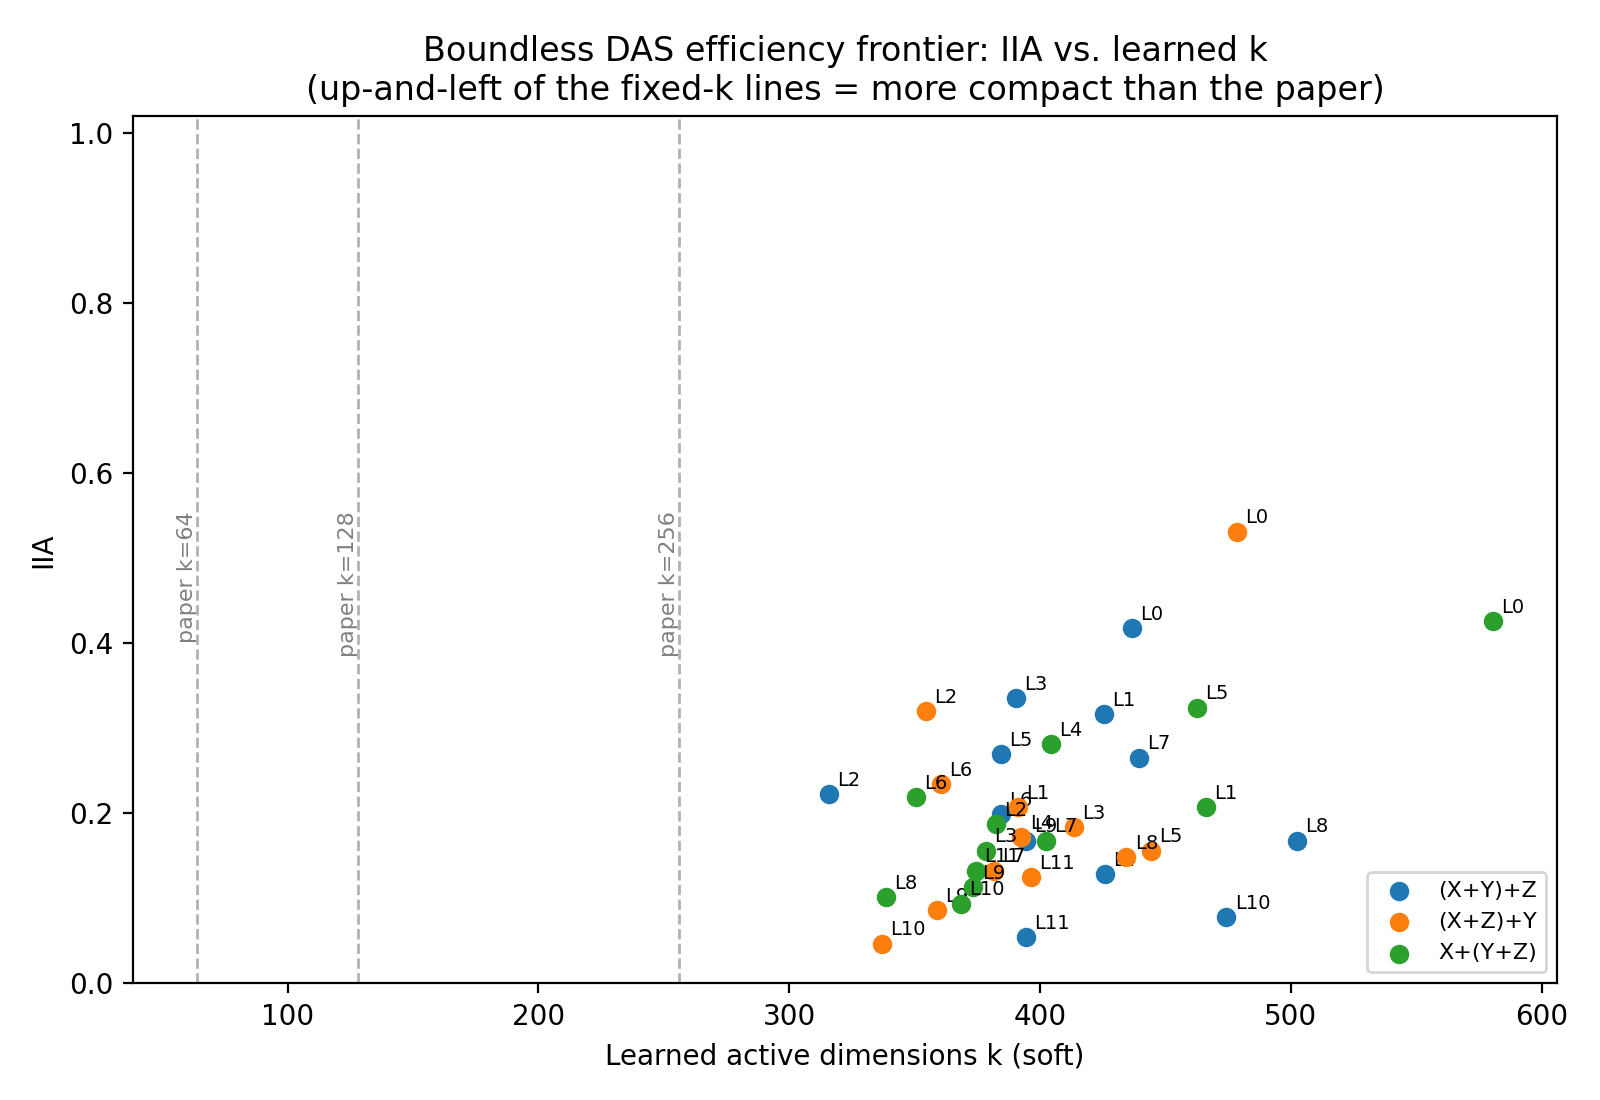

In [4]:
# What has this produced:
show(os.path.join(PLOTS, 'boundless_dimensions.png'))
show(os.path.join(PLOTS, 'boundless_efficiency_frontier.png'))

### What has this produced

* **`boundless_dimensions.png`** — learned `k` per layer for each causal model, against the
  paper's fixed `k = 64/128/256`. Learned `k ≈ 350–580`, **far above** the fixed choices → the
  sum lives in a wide, distributed code, not a compact subspace.
* **`boundless_efficiency_frontier.png`** — each node as `(learned k, IIA)`. All points sit to
  the *right* of `k = 256`, i.e. Boundless is **not** more compact than the paper on this task.

---
## 2. Node-level DAS

`src/run_das_per_node.py` runs DAS but lets you choose *what a node is* via `--granularity`:

| granularity | intervention site | meaning |
|---|---|---|
| `block` | `block_output` | the paper's per-layer, full residual stream |
| `mlp` | `mlp_output` | that layer's MLP contribution |
| `attention` | `attention_output` | that layer's whole attention output |
| `head` | `head_attention_value_output` | one attention head (64 dims) |

The counterfactual data is a genuine `do(P = P_source)` interchange, the metric is IIA.

### How to use it

```bash
# per-head sweep (all layers, all heads, all 3 arithmetic models) at k=64
python3 src/run_das_per_node.py --granularity head --causal_model_type arithmetic \
    --low_rank_dimensions 64 --n_training 25000 --epochs 10 --batch_size 512 --seed 43

# full-stream baseline at the same layers (for comparison)
python3 src/run_das_per_node.py --granularity block --low_rank_dimensions 256 \
    --n_training 25000 --epochs 10 --batch_size 512 --seed 43
```

Run on GPU. `--layers L` / `--heads H` restrict to a single node for a quick test.

### How is its output produced

For each node it builds one `LowRankRotatedSpaceIntervention`, trains only the rotation
(model frozen in `eval()`), evaluates on held-out `do(P)` counterfactuals, and saves a
sklearn `classification_report` whose **`accuracy` field is the IIA**:

```
results/arithmetic/per_node/<gran>/results_<test>/<train>_report_layer_<L>_tkn_<k>_<gran>_L<L>[H<H>].json
```

In [5]:
# Read a per-head report and print its IIA (diagonal, train==test).
pattern = os.path.join(RESULTS, 'arithmetic', 'per_node', 'head', 'results_1',
                       '1_report_layer_*_tkn_64_head_L*H*.json')
files = sorted(glob.glob(pattern))
print(f'found {len(files)} per-head report files')
for f in files[:3]:
    acc = json.load(open(f))['accuracy']
    print(f'  {os.path.basename(f)} : IIA = {acc:.3f}')

found 0 per-head report files


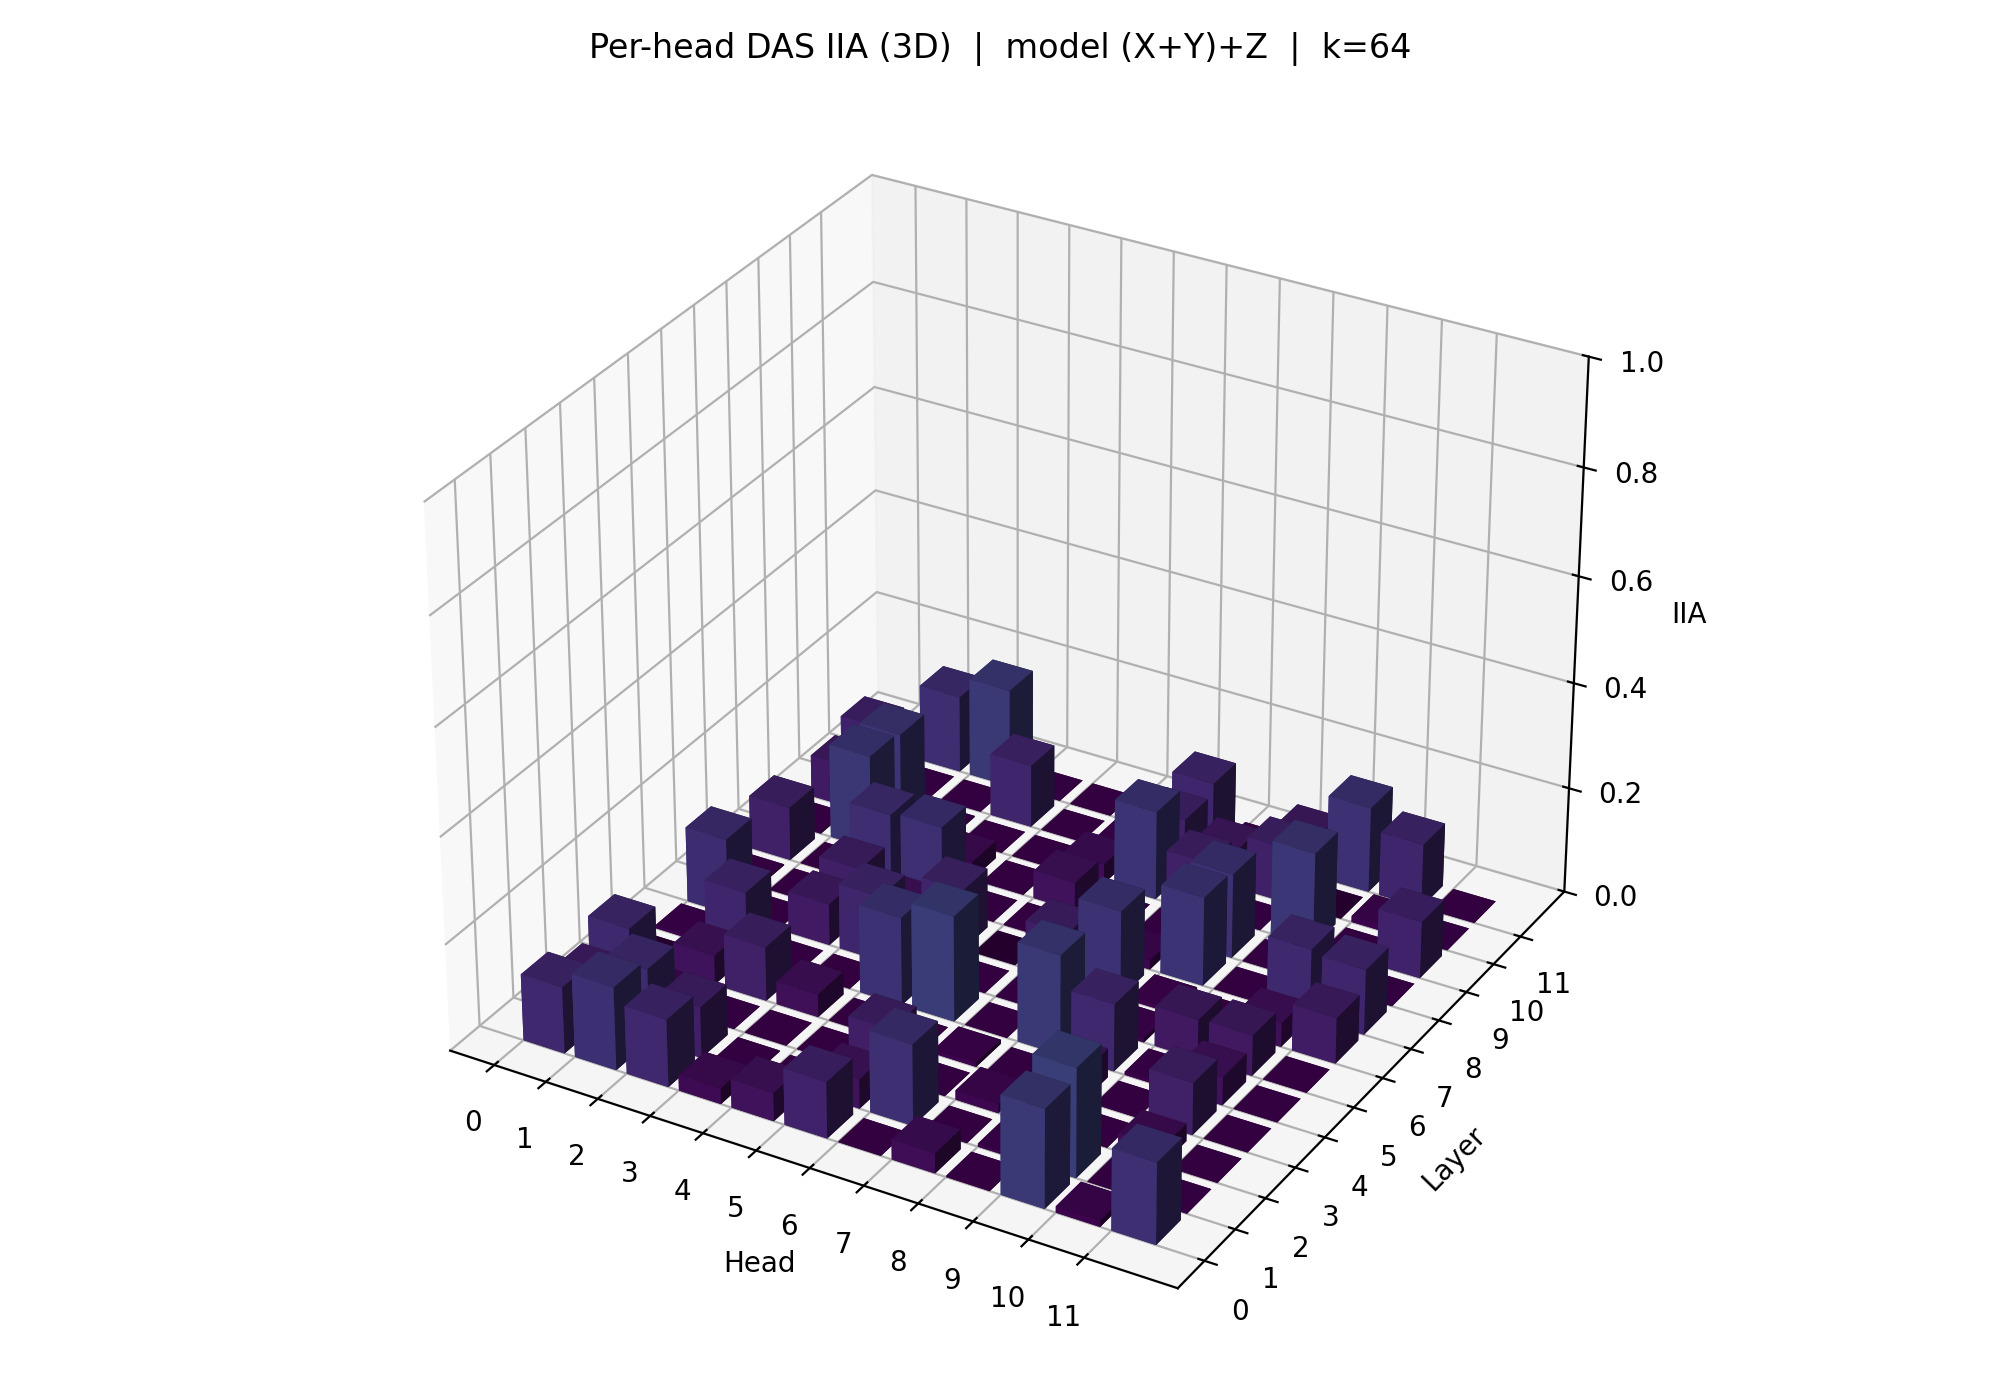

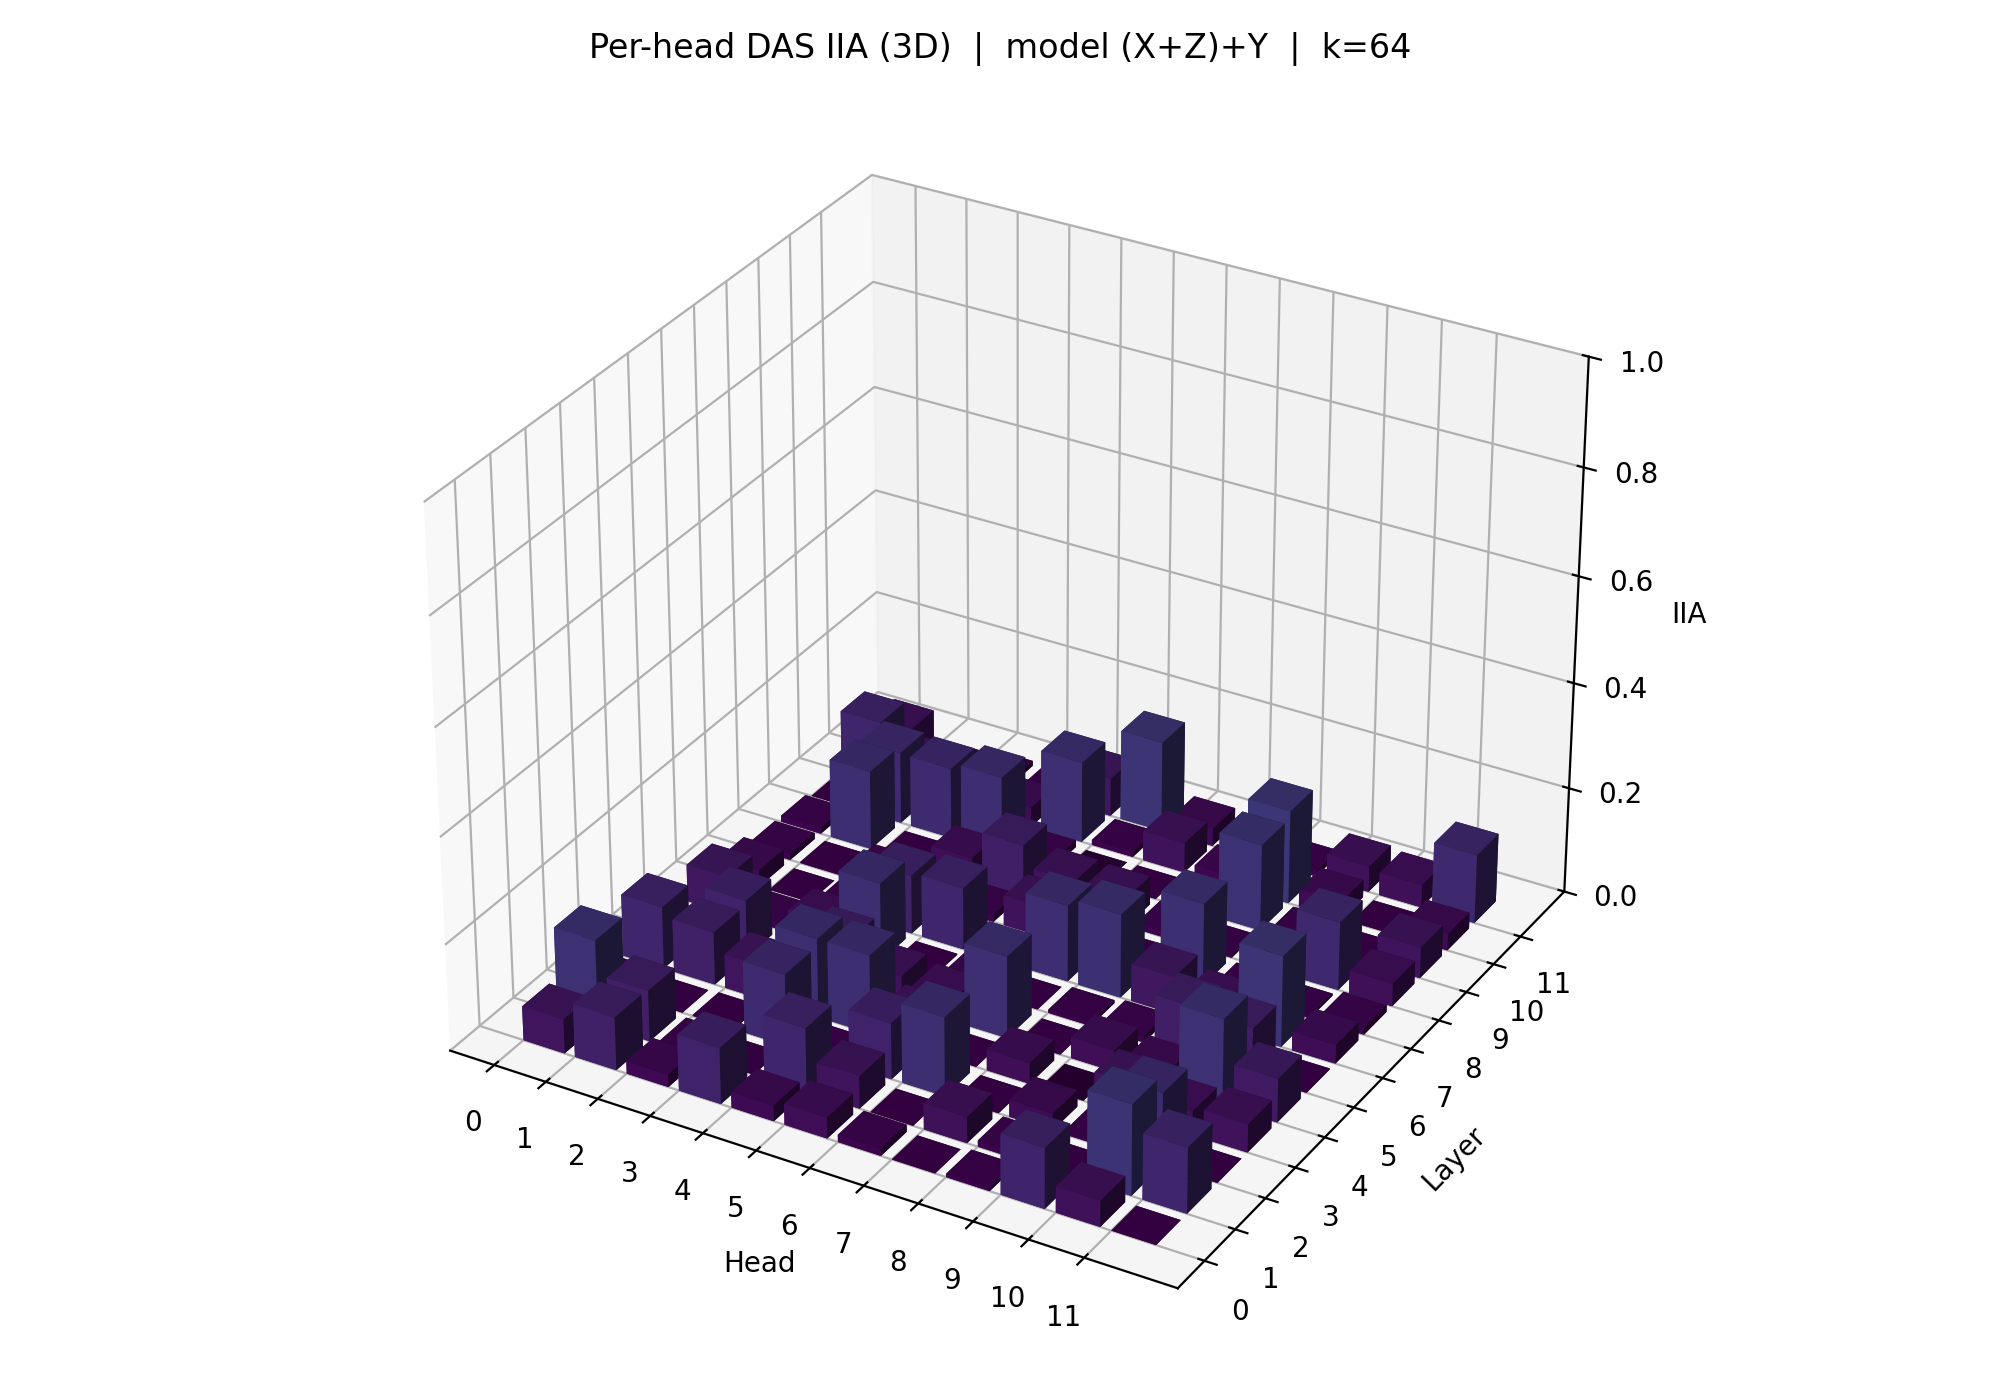

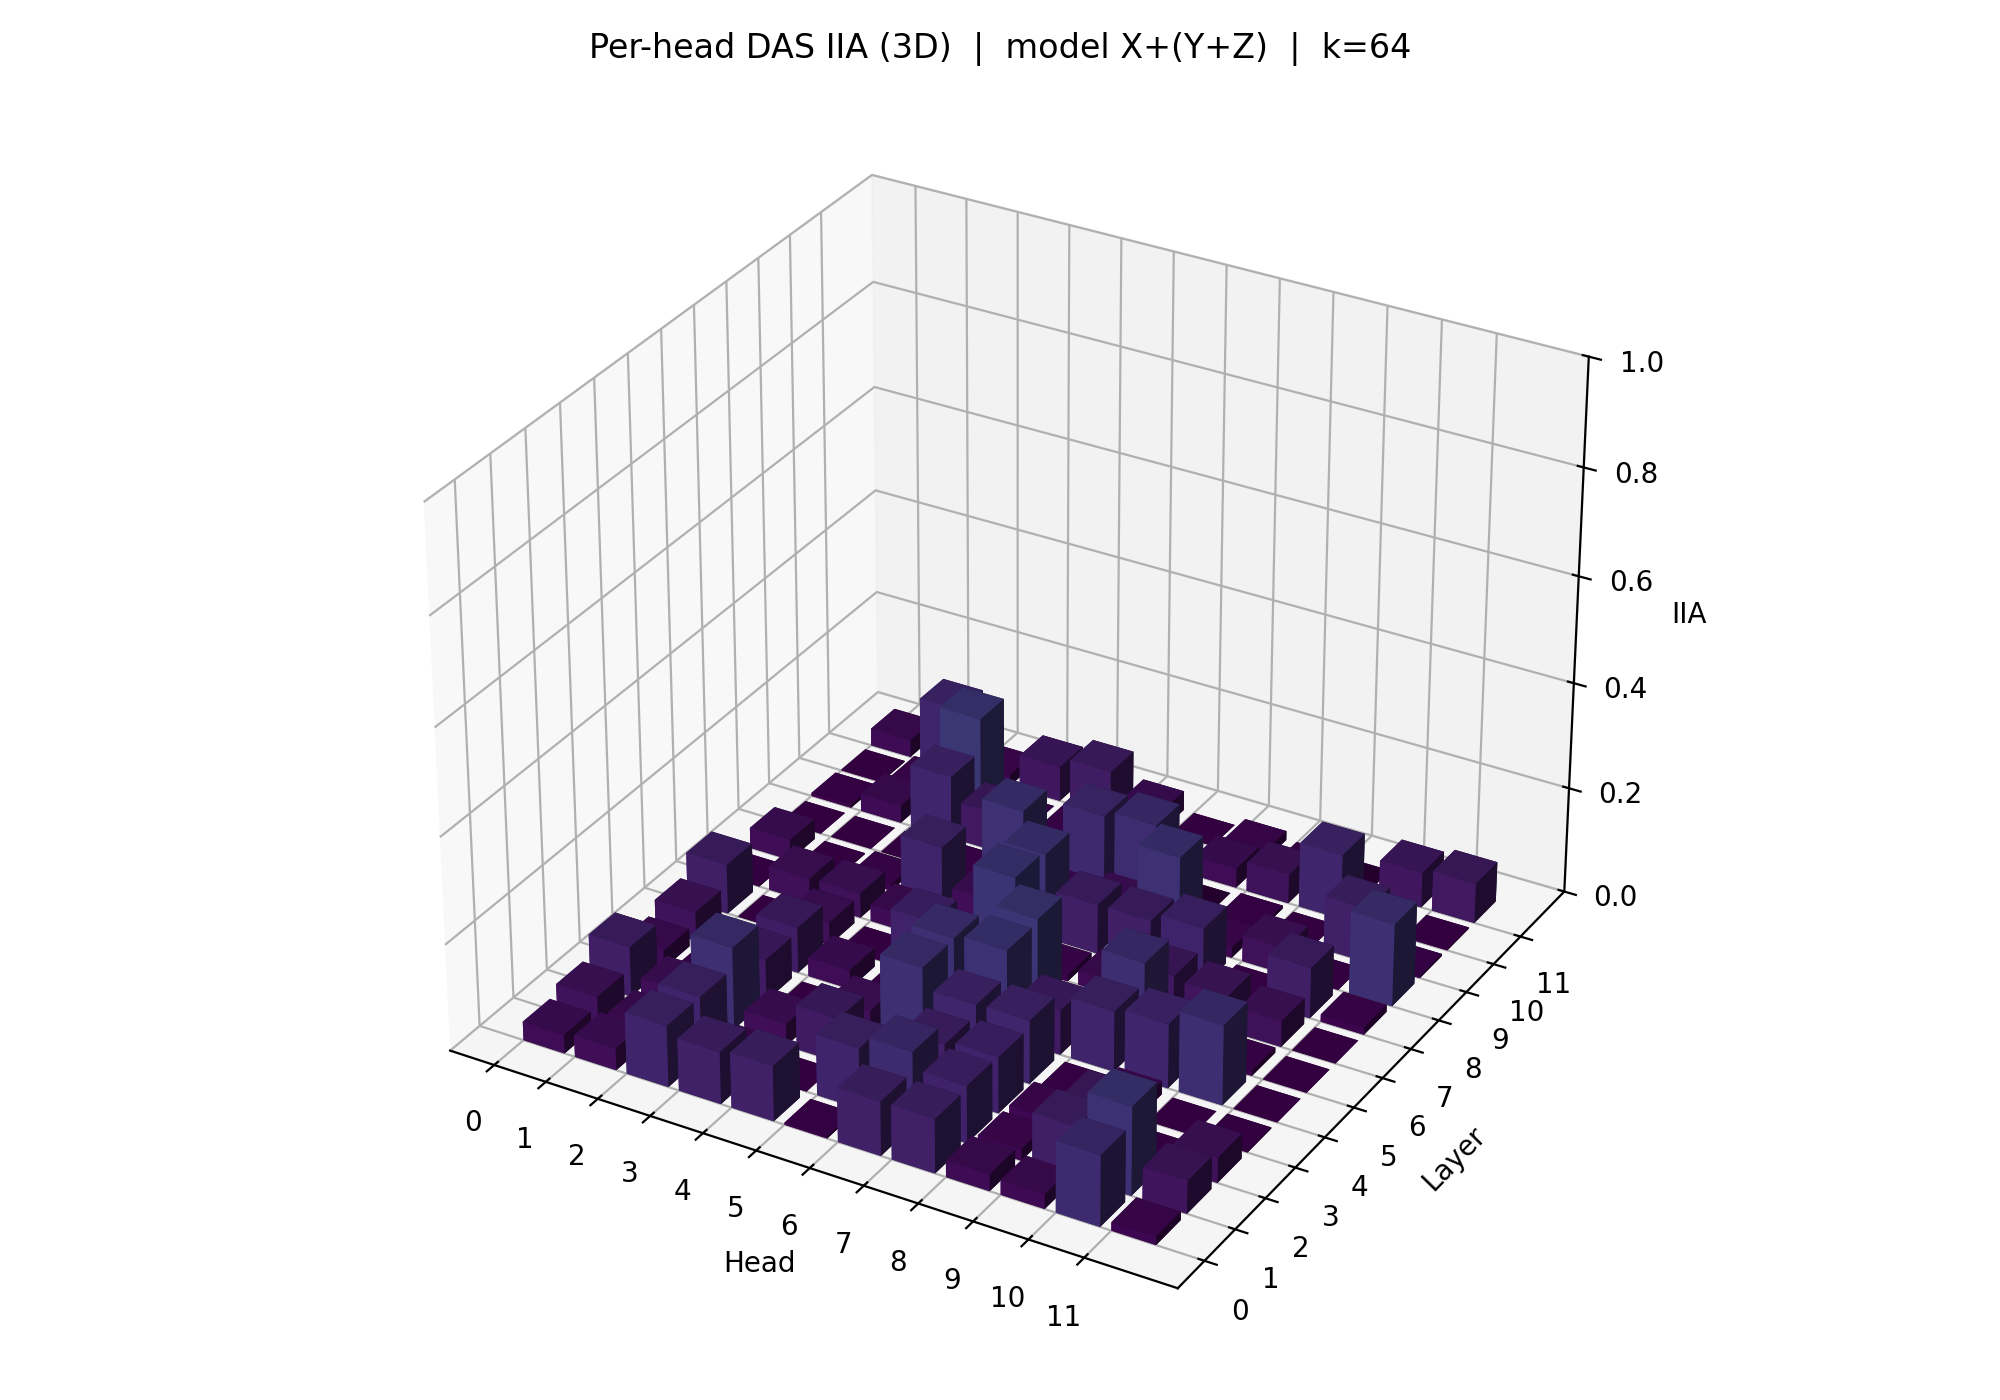

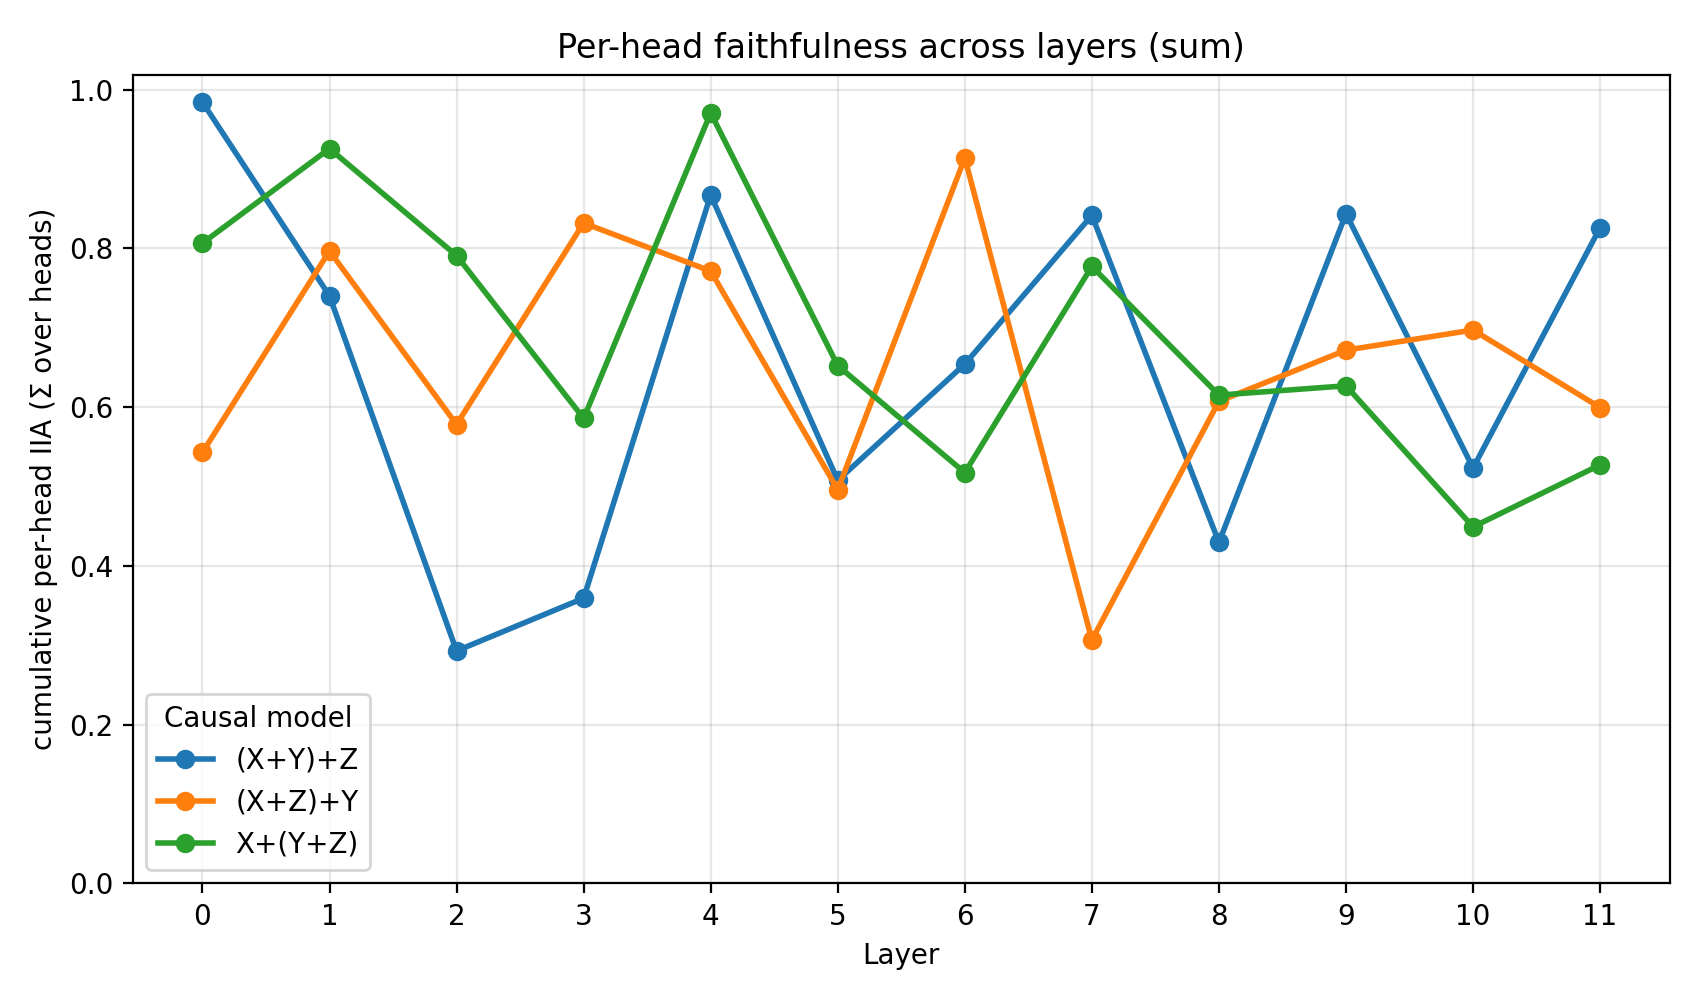

In [6]:
# What has this produced: per-head 3D plots + the cumulative-across-layers plot.
for f in ['perhead_das__X_Y__Z_k64_3d_bar.png',
          'perhead_das__X_Z__Y_k64_3d_bar.png',
          'perhead_das_X__Y_Z__k64_3d_bar.png']:
    show(os.path.join(PLOTS, f), width=560)
show(os.path.join(PLOTS, 'cumulative_faithfulness_sum.png'))

### What has this produced

* **`perhead_das_<model>_k64_3d_bar.png`** — layer×head IIA. Most heads sit near chance, a
  **sparse** set rises above it: `P` is carried by *specific* heads, not spread evenly.
* **`cumulative_faithfulness_sum.png`** — summing the 12 head IIAs per layer gives a **jittery**
  profile with no clean depth trend: single heads are near the noise floor, so the per-layer
  sum is variance-dominated. Consistent with the wide (`k ≈ 400`) Boundless subspace.

---
## 3. Visualization scripts

| script | reads | produces |
|---|---|---|
| `plot_per_node_das.py` | per-node report JSONs | per-head heatmaps + 3D plots (`--plot3d bar`) |
| `plot_cumulative_faithfulness.py` | per-head reports | cumulative-IIA-across-layers line plot |
| `plot_boundless_dimensions.py` | Boundless checkpoints (+ reports) | learned-`k` plot + efficiency frontier |
| `visualize_boundless_das.py` | baseline + Boundless + simple + AtP results | the summary figures (fig1, fig2, fig5, ...) |

### How to use it

```bash
python3 src/plot_per_node_das.py --granularity head --plot3d bar
python3 src/plot_cumulative_faithfulness.py --head_k 64
python3 src/visualize_boundless_das.py          # writes the summary figures
```

### How is its output produced

Each plotting script is a thin reader: it globs the report JSONs (or loads checkpoints),
pulls the `accuracy` / learned boundary, aggregates over layers/heads/models, and draws with
matplotlib. `visualize_boundless_das.py` is the driver that assembles the summary figures
(baseline vs Boundless per layer, per-model comparison, cross-IIA, the simple/copy control,
and AtP).

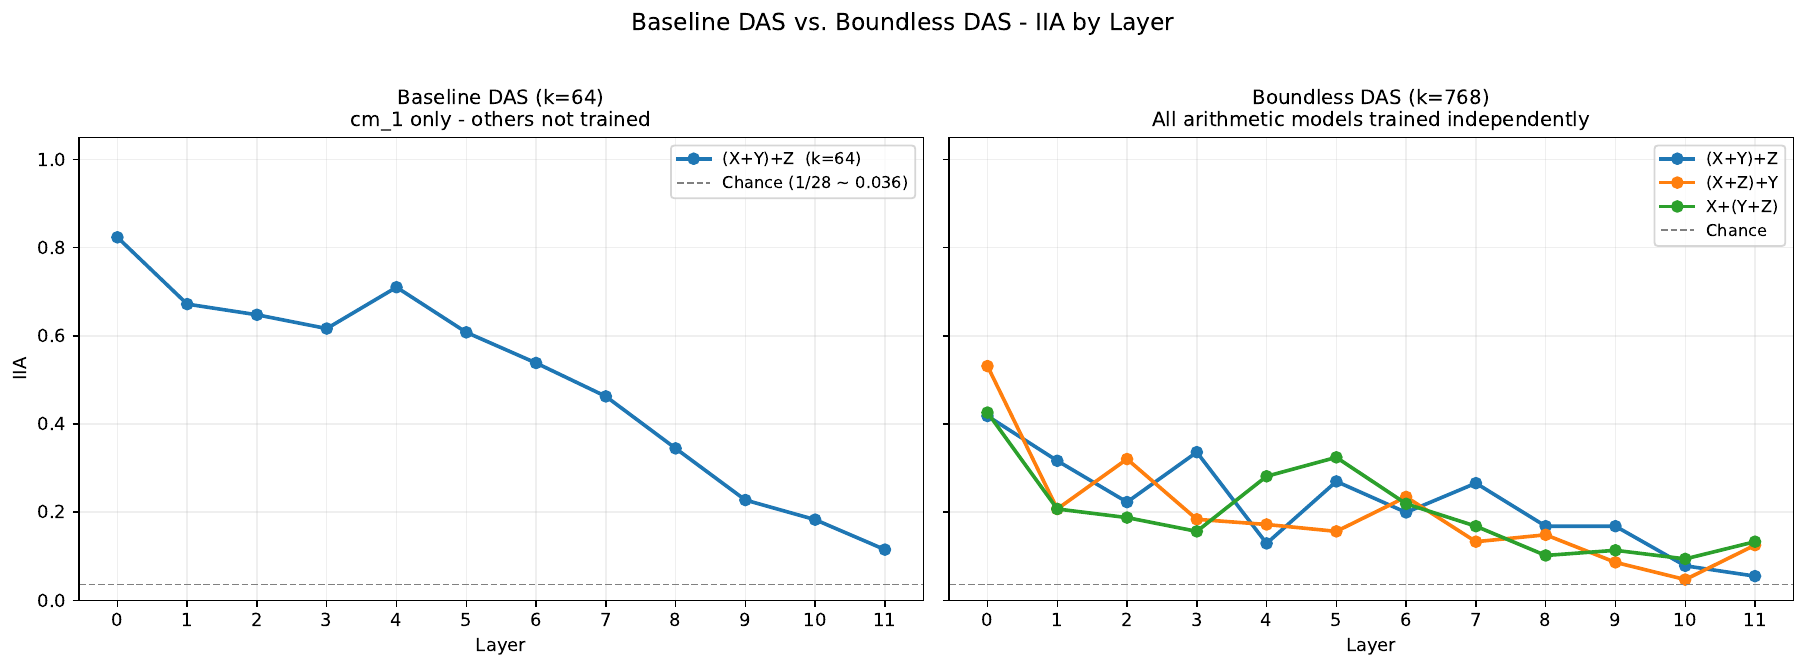

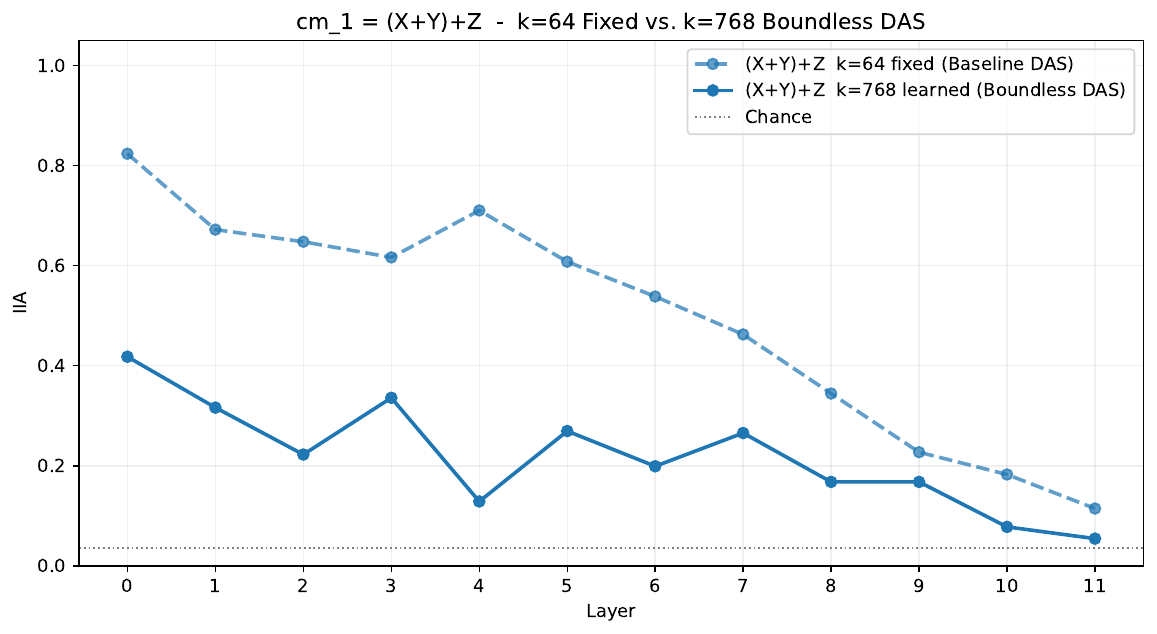

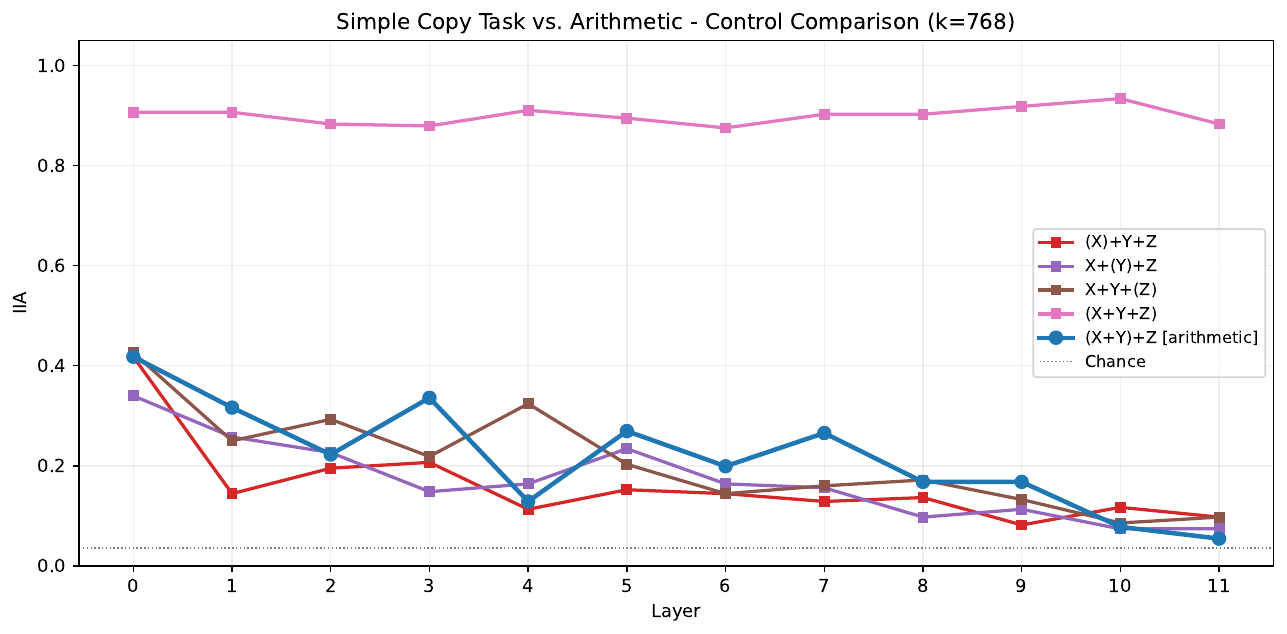

In [7]:
# What has this produced -- the summary figures, rendered inline as PNG.
for f in ['fig1_baseline_vs_boundless.png', 'fig2_cm_comparison.png',
          'fig5_simple_vs_arithmetic.png']:
    show(os.path.join(PLOTS, f), width=860)

### What has this produced

* **`fig1_baseline_vs_boundless`** — baseline (fixed `k=64`) vs Boundless (`k=768`) IIA by layer.
* **`fig2_cm_comparison`** — same model, fixed vs learned `k`.
* **`fig5_simple_vs_arithmetic`** — control: the full-sum / *trivial* model localises
  near-perfectly (~0.9) everywhere → the pipeline works; partial sums are the hard case.

> The figures render inline as PNG above. The original vector `figN_*.pdf` files live in
> `presentation_plots/` and are regenerated by `visualize_boundless_das.py`; refresh the PNGs
> with `pdftoppm -png -r 130 -singlefile figN.pdf figN` after re-running the figures.

---
## File map (where outputs live)

```
results/arithmetic/intervenable_models/cm_<id>/intervenable_768_<L>   # Boundless checkpoints
results/arithmetic/per_node/<gran>/results_<test>/*.json             # node-level IIA reports
results/arithmetic/per_node/<gran>/plots/*.png                       # per-node / cumulative plots
baseline_results/arithmetic/results_<id>/*_tkn_64.json               # fixed-k baseline reports
presentation_plots/  fig1/fig2/fig5 .pdf/.png, atp_*.png, boundless_*.png   # figures for the talk
```